In [126]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [128]:
booking= pd.read_csv('Datasets/Bookings.csv')
session=pd.read_csv('Datasets/Sessions.csv')

In [130]:
# 1  number of distinct bookings,sessions, and searches

distinct_bookings = booking['booking_id'].nunique()
distinct_sessions = session['session_id'].nunique()
distinct_searches = session['search_id'].nunique()

print(f'Distinct Booking {distinct_bookings}')
print(f'Distinct Session {distinct_sessions}')
print(f'Distinct Searches {distinct_searches}')


Distinct Booking 339
Distinct Session 331
Distinct Searches 1360


In [132]:
# 2 sessions have more than one booking 

sessions_with_bookings = session[session['booking_id'].notnull()]
booking_per_session=sessions_with_bookings.groupby("session_id")["booking_id"].nunique()
mutiple_booking=(booking_per_session>1).sum()
print(f'Number of Session having Multiple Booking {mutiple_booking}')

Number of Session having Multiple Booking 10


In [134]:
# 3 Which days of the week have the highest number of bookings , draw a pie chart to 

booking['booking_time'] = pd.to_datetime(booking['booking_time'])
booking['day_of_week'] = booking['booking_time'].dt.day_name() 

bookings_by_day=booking.groupby(['day_of_week'])['day_of_week'].count()
print(bookings_by_day)


day_of_week
Friday       51
Monday       51
Saturday     44
Sunday       35
Thursday     65
Tuesday      59
Wednesday    34
Name: day_of_week, dtype: int64


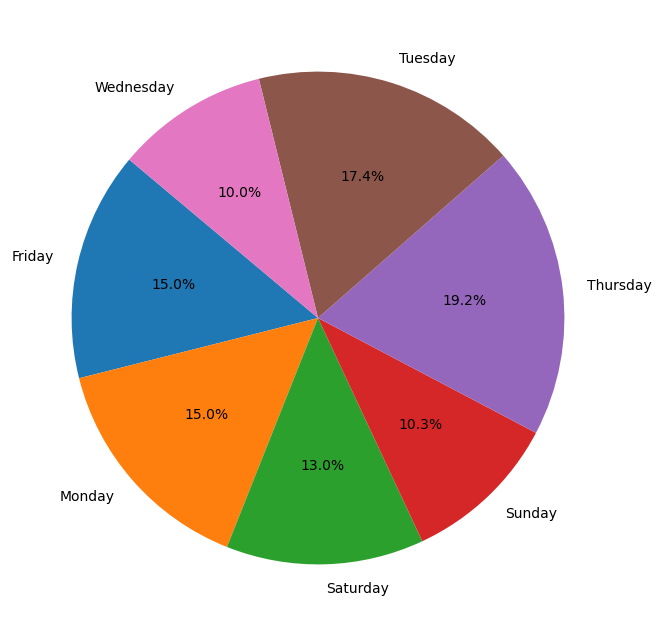

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.pie(bookings_by_day,labels=bookings_by_day.index,autopct='%1.1f%%', startangle=140)
plt.show()

In [60]:
# 4.  For each of the service names,display the total number of bookings and the total Gross # Booking Value in INR

result = booking.groupby('service_name').agg(Total_Booking=("booking_id","count"),Gross_Amount=("INR_Amount","sum"))
print(result)


              Total_Booking  Gross_Amount
service_name                             
GOIBIBO                 186    5897637.97
MMT                      48     665669.08
YATRA                   105    3378702.13


In [62]:
# 5.  For customers who have more than 1 booking, which is the most booked route (from_city to to_city)?

customer_booking_count=booking['customer_id'].value_counts()
multiple_booking=customer_booking_count[customer_booking_count>1].index
multi_booking_customers_df = booking[booking['customer_id'].isin(multiple_booking)]

multi_booking_customers_df = multi_booking_customers_df.copy()
# Create a route column 
multi_booking_customers_df['route'] = (multi_booking_customers_df['from_city'] + " → " + multi_booking_customers_df['to_city'])
most_booked_route = multi_booking_customers_df['route'].value_counts().idxmax()  # most_frequent_value 
most_booked_route_count = multi_booking_customers_df['route'].value_counts().max()

print(f"Most Booked Route : {most_booked_route}  |  Count :  {most_booked_route_count}") 

Most Booked Route : Gurgaon → Roissy-en-France  |  Count :  5


In [64]:
# 6  Which are the top 3 departure cities from where customers book mostly in advance,
     # provided that there have been at least 5 departures from that city

departure_counts = booking['from_city'].value_counts()
cities_with_min_departures = departure_counts[departure_counts >= 5].index
filtered_df = booking[booking['from_city'].isin(cities_with_min_departures)]
avg_days_to_departure = (filtered_df.groupby('from_city')['days_to_departure'].mean().sort_values(ascending=False).head(3))

avg_days_to_departure

from_city
Bālāpur       46.166667
Devanhalli    29.583333
Chennai       26.187500
Name: days_to_departure, dtype: float64

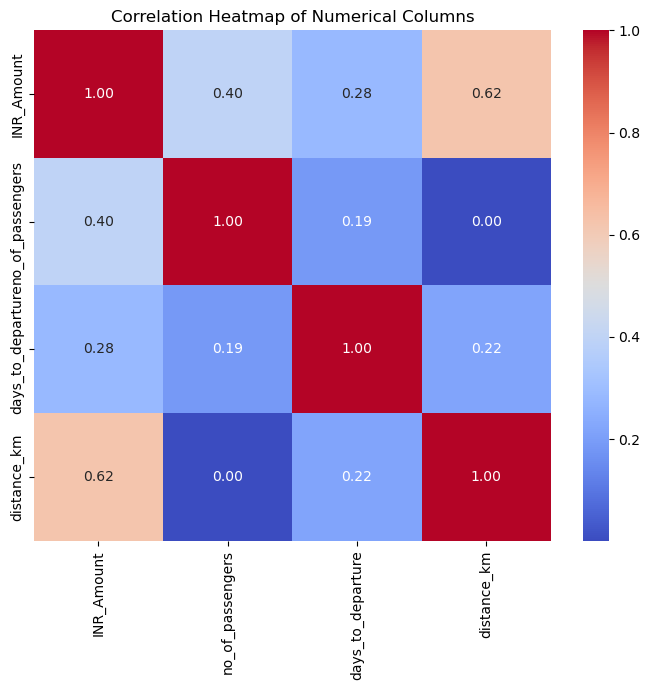

(('INR_Amount', 'distance_km'), 0.6235653096997817)

In [66]:
# 7 Plot a heatmap displaying correlations of the numerical column and report which pair in the bookings dataset, 
#   have the maximum correlation?

numerical_df = booking.select_dtypes(include='number')
correlation_matrix = numerical_df.corr()
plt.figure(figsize=(7,7))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',fmt=".2f")
plt.title('Correlation Heatmap of Numerical Columns')
plt.tight_layout()
plt.show()

# Find the pair with the maximum correlation (excluding self-correlation) 
corr_unstacked = correlation_matrix.where(~np.eye(correlation_matrix.shape[0], dtype=bool)).unstack()
max_corr_pair = corr_unstacked.abs().sort_values(ascending=False).idxmax()
max_corr_value = corr_unstacked[max_corr_pair]

max_corr_pair, max_corr_value

In [68]:
# 8.  For each service, which is the most used device type for making bookings on the platform

device_usage=booking.groupby(['service_name','device_type_used']).size().reset_index(name='Count')
most_used_device=device_usage.sort_values('Count',ascending=False).groupby('service_name').first().reset_index()
most_used_device

,service_name,device_type_used,Count
0,GOIBIBO,IOS,70
1,MMT,Desktop,30
2,YATRA,Desktop,51


C:\Users\ABHAY\AppData\Local\Temp\ipykernel_11600\2256038448.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  booking_df['quarter'] = booking_df['booking_time'].dt.to_period('Q')


<Figure size 1400x700 with 0 Axes>

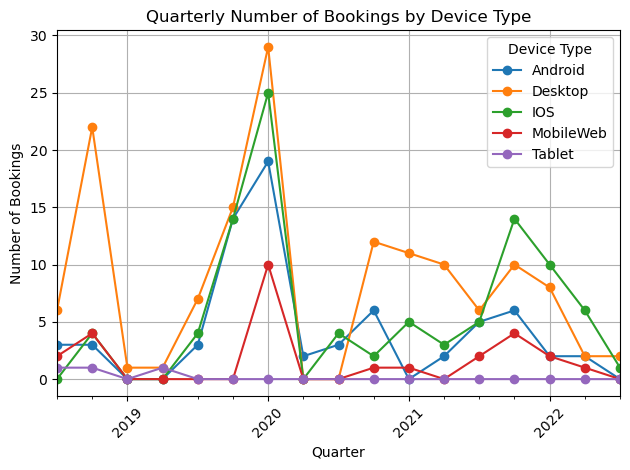

In [78]:
# 9 Plot the trends at a quarterly frequency for the number of bookings by each of the device types, that is , 
# plot a time series for each year and quarter showing the number of bookings performed by each device type
booking_df=booking.copy()

# Convert booking_time to datetime
booking_df['booking_time'] = pd.to_datetime(booking_df['booking_time'])
# Create a 'quarter' column
booking_df['quarter'] = booking_df['booking_time'].dt.to_period('Q')

# Group by quarter and device_type_used, then count the number of bookings
quarterly_trends = booking_df.groupby(['quarter', 'device_type_used']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 7))
quarterly_trends.plot(marker='o')
plt.title('Quarterly Number of Bookings by Device Type')
plt.xlabel('Quarter')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.legend(title='Device Type')
plt.show()



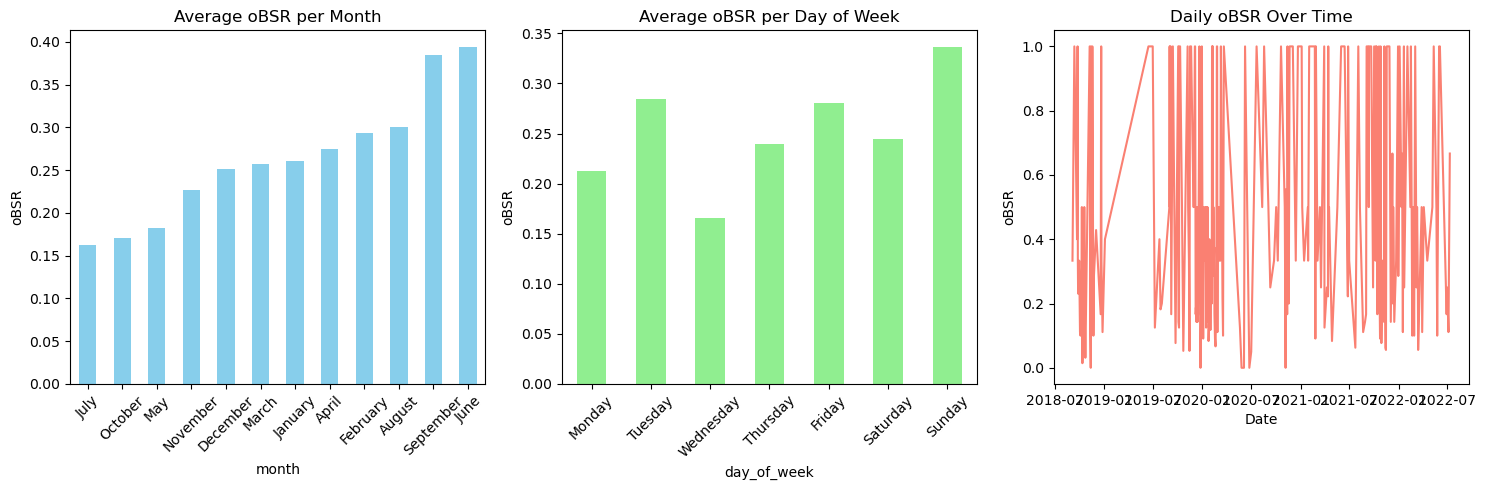

In [124]:
# 10 Overall Booking to Search Ratio (oBSR)
session_df=session.copy()
session_df['search_time']=pd.to_datetime(session_df['search_time'], format='ISO8601')
# add 3 mew column
session_df['month'] = session_df['search_time'].dt.month_name()
session_df['day_of_week'] = session_df['search_time'].dt.day_name()
session_df['date'] = session_df['search_time'].dt.date
session_df['is_booking'] = session_df['booking_id'].notna().astype(int)

# Average oBSR per month
monthly_obsr = session_df.groupby('month')['is_booking'].mean().sort_values()

# Average oBSR per day of week
day_obsr = session_df.groupby('day_of_week')['is_booking'].mean().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday',
'Sunday'])

# Time series of oBSR by date
daily_obsr = session_df.groupby('date')['is_booking'].mean()
daily_obsr

# Plotting
plt.figure(figsize=(15, 5))

# Monthly oBSR
plt.subplot(1, 3, 1)
monthly_obsr.plot(kind='bar', color='skyblue')
plt.title('Average oBSR per Month')
plt.ylabel('oBSR')
plt.xticks(rotation=45)

# Day of week oBSR
plt.subplot(1, 3, 2)
day_obsr.plot(kind='bar', color='lightgreen')
plt.title('Average oBSR per Day of Week')
plt.ylabel('oBSR')
plt.xticks(rotation=45)

# Time series plot of daily oBSR
plt.subplot(1, 3, 3)
daily_obsr.plot(color='salmon')
plt.title('Daily oBSR Over Time')
plt.ylabel('oBSR')
plt.xlabel('Date')
plt.tight_layout()

plt.show()